# End-to-End Fault Detection and Classification

This notebook combines the Mahalanobis gatekeeper from `detection2.ipynb` with the 1D CNN classifier from `new2.ipynb`.

Calibration mode:
- When `CALIBRATION=True`, one held-out `normal/*.csv` file is used to fit calibration statistics for `CalibrationZNormalizer`.
- The calibration file is excluded from train/validation/test splits so the rest of the pipeline is evaluated on unseen files.

Workflow:
1. Split every folder into train, validation, and test at the file level.
2. Optionally reserve one normal file as the calibration reference before any training windows are created.
3. Train the fault detector on every known operating condition, defined here as every folder except `unknown/`.
4. Train the 1D CNN on the same known classes only.
5. Evaluate the cascaded system where the detector short-circuits predicted unknown samples before the classifier runs.


In [574]:
from __future__ import annotations

import copy
import importlib
import json
import os
import random
import sys
from collections import Counter, OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "experiment").exists() and (candidate / "fdd_system").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# The repo used to expose `fdd_system.ML.common.config` as a package.
# Purge cached modules so this notebook can be rerun in the same kernel
# after the flat `config.py` migration without requiring a manual restart.
for module_name in list(sys.modules):
    if module_name.startswith((
        "fdd_system.ML.common.classification",
        "fdd_system.ML.common.config",
        "fdd_system.ML.common.embedder",
        "fdd_system.ML.common.inferrer",
        "fdd_system.ML.common.model",
        "fdd_system.ML.common.preprocessor",
        "fdd_system.ML.common.anomaly_detector",
        "fdd_system.ML.inference",
    )):
        sys.modules.pop(module_name, None)
importlib.invalidate_caches()

from experiment.utils import prepare_training_data
from fdd_system.ML.common.anomaly_detector import save_mahalanobis_gatekeeper
from fdd_system.ML.common.preprocessor import CalibrationZNormalizer, RMSNormalization
from fdd_system.ML.common.config import RawAccWindow
from fdd_system.ML.common.config import OperatingCondition

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Repo root:", ROOT)
print("Device:", DEVICE)


Repo root: /home/btanady/fourth_year/cpen491
Device: cuda


## Data split

The split happens once, before any windowing or preprocessing, so train/validation/test windows never overlap through the same source file.

When `CALIBRATION=True`, one normal file is held out before the split and used only to fit `CalibrationZNormalizer`.
If `CALIBRATION_AUGMENT_TRAIN=True`, the classifier is trained against multiple train-normal calibration references while validation and test still use the single held-out calibration file.


In [ ]:
DATASET_NAME = "data_16"
DATA_PATH = ROOT / "experiment" / DATASET_NAME
UNKNOWN_DIRNAME = "unknown"

REMOVE_FIRST_SECOND = 2.0
COLS = ["X", "Y", "Z"]

TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2
if abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) > 1e-6:
    raise ValueError("TRAIN_RATIO + VAL_RATIO + TEST_RATIO must sum to 1.0")
# Match new2.ipynb exactly: split the remaining files again with test_size=0.2,
# which yields 4 train / 1 val / 2 test files per class for a 7-file dataset.
VAL_SIZE_IN_TRAINVAL = TEST_RATIO

TRIPLET_BATCH_SIZE = 512
TRIPLET_EPOCHS = 40
TRIPLET_MARGIN = 0.5
WEIBULL_Q = 0.97
MAX_PROTOTYPES_PER_CLASS = 6
MIN_WINDOWS_PER_PROTOTYPE = 30
MIN_SILHOUETTE_FOR_SPLIT = 0.05
KMEANS_N_INIT = 10
FILE_WINDOW_SCORE_Q = 0.94
FILE_THRESHOLD_MARGIN = 1.5
AMBIGUITY_RATIO_THRESHOLD = 0.2

CNN_BATCH_SIZE = 64
CNN_EPOCHS = 15
CNN_EARLY_STOP_PATIENCE = 8
CNN_LABEL_SMOOTHING = 0.03
CNN_ARCHITECTURE = "hybrid_timefreq"
CNN_ONNX_OPSET = 18
NOISE_STD_G = 0.002
NOISE_COPIES = 0

CALIBRATION = True
CALIBRATION_FOLDER = "normal"
CALIBRATION_AUGMENT_TRAIN = True

CLASSIFIER_ARTIFACT_PATH = ROOT / "experiment" / "weights" / "end_to_end_cnn1d_hybrid_calaug.pt"
ANOMALY_GATE_ARTIFACT_PATH = ROOT / "experiment" / "weights" / "end_to_end_anomaly_gate.pt"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

KNOWN_FOLDER_TO_LABEL = OrderedDict([
    ("normal", OperatingCondition.NORMAL.value),
    ("blocked", OperatingCondition.BLOCKED_AIRFLOW.value),
    ("interfere", OperatingCondition.BLADE_ISSUE.value),
])
UNKNOWN_LABEL = OperatingCondition.UNKNOWN.value
LABEL_TO_NAME = {
    OperatingCondition.NORMAL.value: "NORMAL",
    OperatingCondition.BLOCKED_AIRFLOW.value: "BLOCKED",
    OperatingCondition.BLADE_ISSUE.value: "INTERFERE",
    UNKNOWN_LABEL: "UNKNOWN",
}

available_folders = sorted(path.name.lower() for path in DATA_PATH.iterdir() if path.is_dir())
unsupported_folders = sorted(set(available_folders) - (set(KNOWN_FOLDER_TO_LABEL) | {UNKNOWN_DIRNAME}))
if unsupported_folders:
    raise ValueError(f"Unsupported folders under {DATA_PATH}: {unsupported_folders}")

known_folders = [folder for folder in KNOWN_FOLDER_TO_LABEL if folder in available_folders]
if not known_folders:
    raise ValueError(f"No known folders found under {DATA_PATH}")
if CALIBRATION and CALIBRATION_FOLDER not in known_folders:
    raise ValueError(f"CALIBRATION_FOLDER '{CALIBRATION_FOLDER}' is not available under {DATA_PATH}")

has_unknown = UNKNOWN_DIRNAME in available_folders


def list_csvs(folder_name: str) -> list[str]:
    return sorted(str(path) for path in (DATA_PATH / folder_name).glob("*.csv"))


def split_files(files: list[str], seed: int = SEED) -> dict[str, list[str]]:
    files = list(files)
    if not files:
        return {"train": [], "val": [], "test": []}

    if len(files) == 1:
        return {"train": files, "val": [], "test": []}
    if len(files) == 2:
        return {"train": files[:1], "val": [], "test": files[1:]}

    trainval_files, test_files = train_test_split(
        files,
        test_size=TEST_RATIO,
        shuffle=True,
        random_state=seed,
    )

    if not trainval_files or VAL_RATIO <= 0:
        return {"train": trainval_files, "val": [], "test": test_files}

    if len(trainval_files) == 1:
        return {"train": trainval_files, "val": [], "test": test_files}

    train_files, val_files = train_test_split(
        trainval_files,
        test_size=VAL_SIZE_IN_TRAINVAL,
        shuffle=True,
        random_state=seed,
    )

    return {
        "train": train_files,
        "val": val_files,
        "test": test_files,
    }


def select_calibration_file(files: list[str], seed: int = SEED) -> tuple[str | None, list[str]]:
    files = list(files)
    if not CALIBRATION:
        return None, files
    if len(files) < 2:
        raise ValueError("CALIBRATION=True requires at least 2 normal files so one can be held out.")

    rng = random.Random(seed)
    calibration_idx = rng.randrange(len(files))
    calibration_file = files.pop(calibration_idx)
    return calibration_file, files


calibration_file_by_folder: dict[str, str] = {}
split_index: OrderedDict[str, dict[str, list[str]]] = OrderedDict()
folders_for_split = known_folders + ([UNKNOWN_DIRNAME] if has_unknown else [])
for folder_name in folders_for_split:
    folder_files = list_csvs(folder_name)
    if CALIBRATION and folder_name == CALIBRATION_FOLDER:
        calibration_file, folder_files = select_calibration_file(folder_files, seed=SEED)
        if calibration_file is None:
            raise RuntimeError("Calibration file selection unexpectedly failed.")
        calibration_file_by_folder[folder_name] = calibration_file
    split_index[folder_name] = split_files(folder_files, seed=SEED)

split_summary = pd.DataFrame(
    [
        {
            "folder": folder_name,
            "calibration_files": int(folder_name in calibration_file_by_folder),
            "train_files": len(parts["train"]),
            "val_files": len(parts["val"]),
            "test_files": len(parts["test"]),
            "total_files": int(folder_name in calibration_file_by_folder) + sum(len(parts[split]) for split in ["train", "val", "test"]),
        }
        for folder_name, parts in split_index.items()
    ]
)
print(split_summary.to_string(index=False))

if CALIBRATION:
    calibration_normal_file = calibration_file_by_folder.get(CALIBRATION_FOLDER)
    print()
    print(
        "Calibration enabled: holding out",
        Path(calibration_normal_file).name,
        f"from '{CALIBRATION_FOLDER}/' for calibration statistics.",
    )
else:
    calibration_normal_file = None

if not has_unknown:
    print()
    print("No unknown/ folder found. UNKNOWN will still appear in the final confusion matrix with zero support.")


def file_map_for(split_name: str, include_unknown: bool = False) -> OrderedDict[int, list[str]]:
    mapping: OrderedDict[int, list[str]] = OrderedDict()
    for folder_name in known_folders:
        mapping[KNOWN_FOLDER_TO_LABEL[folder_name]] = split_index[folder_name][split_name]
    if include_unknown:
        mapping[UNKNOWN_LABEL] = split_index.get(UNKNOWN_DIRNAME, {}).get(split_name, [])
    return mapping


known_train_files = file_map_for("train")
known_val_files = file_map_for("val")
known_test_files = file_map_for("test")
full_test_files = file_map_for("test", include_unknown=True)

print()
print("Known class order:", [LABEL_TO_NAME[KNOWN_FOLDER_TO_LABEL[name]] for name in known_folders])


   folder  calibration_files  train_files  val_files  test_files  total_files
   normal                  1            5          2           2           10
  blocked                  0            6          2           2           10
interfere                  0            4          1           2            7
  unknown                  0            4          1           2            7

Calibration enabled: holding out normal_10.csv from 'normal/' for calibration statistics.

Known class order: ['NORMAL', 'BLOCKED', 'INTERFERE']


In [576]:
calibration_windows_raw: list[RawAccWindow] = []
selected_preprocessor = RMSNormalization()
selected_preprocessor_name = "rms"
selected_preprocessor_kwargs: dict[str, list[float]] = {}
normalization_display_name = "RMS normalization"

if CALIBRATION:
    calibration_label = KNOWN_FOLDER_TO_LABEL[CALIBRATION_FOLDER]
    if calibration_normal_file is None:
        raise ValueError("CALIBRATION=True requires a held-out calibration normal file.")

    calibration_windows_raw = prepare_training_data(
        {int(calibration_label): [calibration_normal_file]},
        shuffle=False,
        col_names=COLS,
        remove_first_second=REMOVE_FIRST_SECOND,
    )
    if not calibration_windows_raw:
        raise ValueError(f"Calibration file produced no windows: {calibration_normal_file}")

    selected_preprocessor = CalibrationZNormalizer.fit(calibration_windows_raw)
    selected_preprocessor_name = "calibration_z"
    selected_preprocessor_kwargs = selected_preprocessor.export_kwargs()
    normalization_display_name = "calibration z-normalization"


def prepare_windows_for_map(file_map: OrderedDict[int, list[str]], shuffle: bool) -> list[RawAccWindow]:
    windows = prepare_training_data(
        file_map,
        shuffle=shuffle,
        col_names=COLS,
        remove_first_second=REMOVE_FIRST_SECOND,
    )
    return selected_preprocessor.preprocess(windows)


def prepare_raw_windows_for_map(file_map: OrderedDict[int, list[str]], shuffle: bool) -> list[RawAccWindow]:
    return prepare_training_data(
        file_map,
        shuffle=shuffle,
        col_names=COLS,
        remove_first_second=REMOVE_FIRST_SECOND,
    )


def prepare_grouped_windows_for_map(file_map: OrderedDict[int, list[str]]):
    grouped = []
    for label, paths in file_map.items():
        for path in paths:
            windows = prepare_training_data(
                {int(label): [path]},
                shuffle=False,
                col_names=COLS,
                remove_first_second=REMOVE_FIRST_SECOND,
            )
            windows = selected_preprocessor.preprocess(windows)
            if not windows:
                continue
            grouped.append({
                "label": int(label),
                "path": str(path),
                "windows": windows,
            })
    return grouped


def stack_windows(windows: list[RawAccWindow], target_len: int | None = None):
    if not windows:
        raise ValueError("No windows found for the requested split.")

    if target_len is None:
        target_len = min(
            min(len(window.acc_x), len(window.acc_y), len(window.acc_z))
            for window in windows
        )

    X = np.empty((len(windows), 3, target_len), dtype=np.float32)
    y = np.empty((len(windows),), dtype=np.int64)

    for idx, window in enumerate(windows):
        X[idx, 0] = np.asarray(window.acc_x, dtype=np.float32)[:target_len]
        X[idx, 1] = np.asarray(window.acc_y, dtype=np.float32)[:target_len]
        X[idx, 2] = np.asarray(window.acc_z, dtype=np.float32)[:target_len]
        y[idx] = int(window.label)

    return X, y, target_len


def build_group_feature_batches(grouped_windows, target_len, mean, std):
    feature_groups = []
    for group in grouped_windows:
        X_group_raw, y_group, _ = stack_windows(group["windows"], target_len=target_len)
        feature_groups.append({
            "label": int(group["label"]),
            "path": group["path"],
            "num_windows": int(len(y_group)),
            "X": (X_group_raw - mean) / std,
            "y": y_group,
        })
    return feature_groups


def named_label_counts(labels: np.ndarray) -> dict[str, int]:
    counts = Counter(int(label) for label in labels.tolist())
    return {LABEL_TO_NAME.get(label, str(label)): counts[label] for label in sorted(counts)}


def with_noise(window: RawAccWindow, noise_std: float) -> RawAccWindow:
    return RawAccWindow(
        acc_x=window.acc_x + np.random.normal(0, noise_std, size=window.acc_x.shape),
        acc_y=window.acc_y + np.random.normal(0, noise_std, size=window.acc_y.shape),
        acc_z=window.acc_z + np.random.normal(0, noise_std, size=window.acc_z.shape),
        label=window.label,
        device_id=window.device_id,
        timestamps=window.timestamps,
        sampling_rate_hz=window.sampling_rate_hz,
        acc_mag=window.acc_mag,
    )


known_train_raw_pre = prepare_raw_windows_for_map(known_train_files, shuffle=True)
known_train_pre = selected_preprocessor.preprocess(known_train_raw_pre)
known_val_pre = prepare_windows_for_map(known_val_files, shuffle=False)
known_test_pre = prepare_windows_for_map(known_test_files, shuffle=False)
full_test_pre = prepare_windows_for_map(full_test_files, shuffle=False)

known_train_grouped_pre = prepare_grouped_windows_for_map(known_train_files)
known_val_grouped_pre = prepare_grouped_windows_for_map(known_val_files)

print(f"Window counts after {normalization_display_name}:")
for split_name, windows in [
    ("known_train", known_train_pre),
    ("known_val", known_val_pre),
    ("known_test", known_test_pre),
    ("full_test", full_test_pre),
]:
    labels = np.array([int(window.label) for window in windows], dtype=np.int64)
    print(f"  {split_name:11s}: {len(windows):4d} windows -> {named_label_counts(labels)}")

if CALIBRATION:
    calibration_stats = pd.DataFrame([
        {
            "calibration_file": Path(calibration_normal_file).name,
            "num_windows": int(len(calibration_windows_raw)),
            "axis_mean_x": float(selected_preprocessor.axis_mean[0]),
            "axis_mean_y": float(selected_preprocessor.axis_mean[1]),
            "axis_mean_z": float(selected_preprocessor.axis_mean[2]),
            "axis_std_x": float(selected_preprocessor.axis_std[0]),
            "axis_std_y": float(selected_preprocessor.axis_std[1]),
            "axis_std_z": float(selected_preprocessor.axis_std[2]),
        }
    ])
    print()
    print("Calibration stats:")
    print(calibration_stats.to_string(index=False))

classifier_train_pre = list(known_train_pre)
classifier_train_calibration_files: list[str] = []
if CALIBRATION and CALIBRATION_AUGMENT_TRAIN:
    classifier_train_pre = []
    calibration_label = KNOWN_FOLDER_TO_LABEL[CALIBRATION_FOLDER]
    for calibration_path in split_index[CALIBRATION_FOLDER]["train"]:
        calibration_windows = prepare_training_data(
            {int(calibration_label): [calibration_path]},
            shuffle=False,
            col_names=COLS,
            remove_first_second=REMOVE_FIRST_SECOND,
        )
        if not calibration_windows:
            continue
        train_calibrator = CalibrationZNormalizer.fit(calibration_windows)
        classifier_train_pre.extend(train_calibrator.preprocess(known_train_raw_pre))
        classifier_train_calibration_files.append(Path(calibration_path).name)
    if classifier_train_pre:
        print(
            f"Classifier calibration augmentation enabled: {len(classifier_train_calibration_files)} train normal files "
            f"produced {len(classifier_train_pre)} classifier windows."
        )
    else:
        classifier_train_pre = list(known_train_pre)
        print("Classifier calibration augmentation produced no windows; falling back to held-out calibration only.")
else:
    print("Classifier calibration augmentation disabled; using held-out calibration only.")

if NOISE_COPIES > 0 and NOISE_STD_G > 0:
    noisy_windows = []
    for _ in range(NOISE_COPIES):
        noisy_windows.extend(with_noise(window, NOISE_STD_G) for window in classifier_train_pre)
    classifier_train_pre = classifier_train_pre + noisy_windows
    print(f"Added {len(noisy_windows)} noisy windows to the classifier training split.")
else:
    print("Noise augmentation disabled for the CNN stage.")

X_train_known_raw, y_train_known_raw, target_len = stack_windows(known_train_pre)
X_val_known_raw, y_val_known_raw, _ = stack_windows(known_val_pre, target_len=target_len)
X_known_test_raw, y_known_test_raw, _ = stack_windows(known_test_pre, target_len=target_len)
X_full_test_raw, y_full_test_raw, _ = stack_windows(full_test_pre, target_len=target_len)
X_train_classifier_raw, y_train_classifier_raw, _ = stack_windows(classifier_train_pre, target_len=target_len)

mean = X_train_known_raw.mean(axis=(0, 2), keepdims=True)
std = X_train_known_raw.std(axis=(0, 2), keepdims=True) + 1e-6

X_train_known = (X_train_known_raw - mean) / std
X_val_known = (X_val_known_raw - mean) / std
X_known_test = (X_known_test_raw - mean) / std
X_full_test = (X_full_test_raw - mean) / std

classifier_mean = X_train_classifier_raw.mean(axis=(0, 2), keepdims=True)
classifier_std = X_train_classifier_raw.std(axis=(0, 2), keepdims=True) + 1e-6

X_train_classifier = (X_train_classifier_raw - classifier_mean) / classifier_std
X_val_classifier_input = (X_val_known_raw - classifier_mean) / classifier_std
X_known_test_classifier_input = (X_known_test_raw - classifier_mean) / classifier_std
X_full_test_classifier_input = (X_full_test_raw - classifier_mean) / classifier_std

known_train_feature_groups = build_group_feature_batches(known_train_grouped_pre, target_len, mean, std)
known_val_feature_groups = build_group_feature_batches(known_val_grouped_pre, target_len, mean, std)

known_labels = sorted({*y_train_known_raw.tolist(), *y_val_known_raw.tolist(), *y_known_test_raw.tolist()})
classifier_label_to_idx = {label: idx for idx, label in enumerate(known_labels)}
classifier_idx_to_label = {idx: label for label, idx in classifier_label_to_idx.items()}

y_train_classifier = np.array([classifier_label_to_idx[int(label)] for label in y_train_classifier_raw], dtype=np.int64)
y_val_classifier = np.array([classifier_label_to_idx[int(label)] for label in y_val_known_raw], dtype=np.int64)
y_known_test_classifier = np.array([classifier_label_to_idx[int(label)] for label in y_known_test_raw], dtype=np.int64)

train_file_counts = {LABEL_TO_NAME[label]: sum(group["label"] == label for group in known_train_feature_groups) for label in known_labels}
val_file_counts = {LABEL_TO_NAME[label]: sum(group["label"] == label for group in known_val_feature_groups) for label in known_labels}

print()
print("Tensor shapes:")
print("  preprocessor:   ", selected_preprocessor_name)
print("  detector train:", X_train_known.shape)
print("  detector val:  ", X_val_known.shape)
print("  known test:    ", X_known_test.shape)
print("  full test:     ", X_full_test.shape)
print("  classifier architecture:", CNN_ARCHITECTURE)
print("  classifier train tensor:", X_train_classifier.shape)
print("  classifier val tensor:  ", X_val_classifier_input.shape)
print("  classifier train labels:", named_label_counts(y_train_classifier_raw))
print("  classifier calibration files:", classifier_train_calibration_files or ["held_out_only"])
print("  calibration train files:", train_file_counts)
print("  calibration val files:  ", val_file_counts)


Window counts after calibration z-normalization:
  known_train:  615 windows -> {'NORMAL': 205, 'BLOCKED': 246, 'INTERFERE': 164}
  known_val  :  205 windows -> {'NORMAL': 82, 'BLOCKED': 82, 'INTERFERE': 41}
  known_test :  246 windows -> {'NORMAL': 82, 'BLOCKED': 82, 'INTERFERE': 82}
  full_test  :  328 windows -> {'NORMAL': 82, 'BLOCKED': 82, 'INTERFERE': 82, 'UNKNOWN': 82}

Calibration stats:
calibration_file  num_windows  axis_mean_x  axis_mean_y  axis_mean_z  axis_std_x  axis_std_y   axis_std_z
   normal_10.csv           41     50.25634  -404.544098        511.0     7.14558    4.703865 1.000000e-08
Classifier calibration augmentation enabled: 5 train normal files produced 3075 classifier windows.
Noise augmentation disabled for the CNN stage.

Tensor shapes:
  preprocessor:    calibration_z
  detector train: (615, 3, 1000)
  detector val:   (205, 3, 1000)
  known test:     (246, 3, 1000)
  full test:      (328, 3, 1000)
  classifier architecture: hybrid_timefreq
  classifier train

## Section 1: Fault detection

Train the Mahalanobis gatekeeper on every known operating condition. Unknown data is excluded from training and only appears in the held-out evaluation split.
        

In [577]:
def plot_confusion(y_true, y_pred, labels, display_labels, title, figsize=(4, 4), values_format="d"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=figsize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax, cmap="Blues", values_format=values_format, colorbar=False)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.tight_layout()
    plt.show()
    return cm


def plot_true_label_binary_confusion(
    y_true_labels,
    y_pred_binary,
    true_labels,
    true_display_labels,
    title,
    pred_display_labels=("known", "unknown"),
    figsize=(4.8, 4.2),
):
    cm = np.zeros((len(true_labels), len(pred_display_labels)), dtype=int)
    for row, true_label in enumerate(true_labels):
        mask = y_true_labels == true_label
        if not np.any(mask):
            continue
        for col, pred_label in enumerate(range(len(pred_display_labels))):
            cm[row, col] = int(np.sum(mask & (y_pred_binary == pred_label)))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(len(pred_display_labels)))
    ax.set_xticklabels(pred_display_labels)
    ax.set_yticks(range(len(true_display_labels)))
    ax.set_yticklabels(true_display_labels)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    threshold = cm.max() / 2.0 if cm.size else 0.0
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            color = "white" if cm[row, col] > threshold else "black"
            ax.text(col, row, str(cm[row, col]), ha="center", va="center", color=color)

    plt.tight_layout()
    plt.show()
    return cm


def batch_hard_triplet_loss(embeddings, labels, margin=0.5):
    if embeddings.size(0) < 2:
        return torch.tensor(0.0, device=embeddings.device)

    distances = torch.cdist(embeddings, embeddings, p=2)
    labels = labels.view(-1, 1)
    positive_mask = labels == labels.T
    negative_mask = labels != labels.T
    positive_mask.fill_diagonal_(False)

    positive_distances = distances.clone()
    positive_distances[~positive_mask] = -1.0
    hardest_positive, _ = positive_distances.max(dim=1)

    negative_distances = distances.clone()
    negative_distances[~negative_mask] = float("inf")
    hardest_negative, _ = negative_distances.min(dim=1)

    valid = (hardest_positive >= 0) & torch.isfinite(hardest_negative)
    if valid.sum() == 0:
        return torch.tensor(0.0, device=embeddings.device)

    return F.relu(hardest_positive[valid] - hardest_negative[valid] + margin).mean()


class TripletCNN(nn.Module):
    def __init__(self, in_channels=3, out_dim=16):
        super().__init__()
        self.time_branch = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.freq_branch = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=3, dilation=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, dilation=4, padding=4),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, dilation=8, padding=8),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, out_dim),
        )

    def forward(self, x):
        time_emb = self.time_branch(x)
        freq = torch.abs(torch.fft.rfft(x, dim=2))
        freq_emb = self.freq_branch(freq)
        embedding = torch.cat([time_emb, freq_emb], dim=1)
        return self.proj(embedding)


def train_triplet_encoder_raw(x_train, y_train, emb_dim=16, epochs=40, batch_size=512, lr=1e-3, margin=0.5):
    model = TripletCNN(in_channels=x_train.shape[1], out_dim=emb_dim).to(DEVICE)
    dataset = TensorDataset(torch.from_numpy(x_train).float(), torch.from_numpy(y_train).long())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            embeddings = model(xb)
            loss = batch_hard_triplet_loss(embeddings, yb, margin=margin)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * yb.size(0)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            avg_loss = total_loss / max(len(loader.dataset), 1)
            print(f"triplet epoch={epoch:02d} loss={avg_loss:.4f}")

    return model


@torch.no_grad()
def encode_embeddings_raw(model, x_np, batch_size=512):
    model.eval()
    embeddings = []
    for start in range(0, len(x_np), batch_size):
        xb = torch.from_numpy(x_np[start:start + batch_size]).float().to(DEVICE)
        embeddings.append(model(xb).cpu().numpy())
    return np.vstack(embeddings)


def _covariance_inverse(class_embeddings, reg=1e-3):
    feature_dim = class_embeddings.shape[1]
    if len(class_embeddings) < 2:
        cov = np.eye(feature_dim, dtype=np.float32)
    else:
        cov = np.cov(class_embeddings, rowvar=False)
        cov = np.atleast_2d(cov)
    cov = cov + reg * np.eye(feature_dim, dtype=np.float32)
    return np.linalg.pinv(cov)


def select_num_prototypes(class_embeddings):
    max_k = min(MAX_PROTOTYPES_PER_CLASS, len(class_embeddings) // MIN_WINDOWS_PER_PROTOTYPE)
    if max_k < 2:
        return 1, None, float("nan")

    best_k = 1
    best_labels = None
    best_score = float("-inf")

    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=KMEANS_N_INIT)
        cluster_labels = kmeans.fit_predict(class_embeddings)
        counts = np.bincount(cluster_labels, minlength=k)
        if counts.min() < MIN_WINDOWS_PER_PROTOTYPE:
            continue
        score = silhouette_score(class_embeddings, cluster_labels)
        if score > max(best_score, MIN_SILHOUETTE_FOR_SPLIT):
            best_k = k
            best_labels = cluster_labels
            best_score = float(score)

    if best_k == 1:
        return 1, None, float("nan")
    return best_k, best_labels, best_score


def build_multi_prototype_stats(embeddings, labels, reg=1e-3):
    prototype_table = []
    class_details = {}

    for label in sorted(set(labels.tolist())):
        class_embeddings = embeddings[labels == label]
        if len(class_embeddings) == 0:
            continue

        num_prototypes, cluster_labels, silhouette = select_num_prototypes(class_embeddings)
        if cluster_labels is None:
            cluster_labels = np.zeros(len(class_embeddings), dtype=np.int64)

        cluster_sizes = []
        for prototype_index in range(num_prototypes):
            cluster_embeddings = class_embeddings[cluster_labels == prototype_index]
            cluster_sizes.append(int(len(cluster_embeddings)))
            prototype_table.append({
                "label": int(label),
                "prototype_index": int(prototype_index),
                "mu": cluster_embeddings.mean(axis=0),
                "inv_cov": _covariance_inverse(cluster_embeddings, reg=reg),
                "num_samples": int(len(cluster_embeddings)),
            })

        class_details[int(label)] = {
            "num_prototypes": int(num_prototypes),
            "cluster_sizes": cluster_sizes,
            "silhouette_score": float(silhouette) if np.isfinite(silhouette) else float("nan"),
        }

    return prototype_table, class_details


def prototype_distance_matrix(embeddings, prototype_table):
    if not prototype_table:
        return [], np.empty((len(embeddings), 0), dtype=np.float32)

    owner_labels = [entry["label"] for entry in prototype_table]
    distances = np.zeros((len(embeddings), len(prototype_table)), dtype=np.float32)
    for column, entry in enumerate(prototype_table):
        diff = embeddings - entry["mu"]
        dist_sq = np.einsum("bi,ij,bj->b", diff, entry["inv_cov"], diff)
        distances[:, column] = np.sqrt(np.maximum(dist_sq, 0.0))
    return owner_labels, distances


def multi_prototype_scores(embeddings, prototype_table):
    owner_labels, prototype_distances = prototype_distance_matrix(embeddings, prototype_table)
    if not owner_labels:
        return {
            "nearest_distance": np.full(len(embeddings), np.inf, dtype=np.float32),
            "nearest_label": np.full(len(embeddings), -1, dtype=np.int64),
            "nearest_prototype": np.full(len(embeddings), -1, dtype=np.int64),
            "second_distance": np.full(len(embeddings), np.inf, dtype=np.float32),
            "second_label": np.full(len(embeddings), -1, dtype=np.int64),
            "distance_ratio": np.full(len(embeddings), np.inf, dtype=np.float32),
            "distance_gap": np.full(len(embeddings), 0.0, dtype=np.float32),
        }

    nearest_prototype = np.argmin(prototype_distances, axis=1).astype(np.int64)
    unique_labels = sorted(set(owner_labels))
    class_distances = np.full((len(embeddings), len(unique_labels)), np.inf, dtype=np.float32)
    for column, label in enumerate(unique_labels):
        class_columns = [idx for idx, owner_label in enumerate(owner_labels) if owner_label == label]
        class_distances[:, column] = prototype_distances[:, class_columns].min(axis=1)

    class_order = np.argsort(class_distances, axis=1)
    nearest_class_index = class_order[:, 0]
    nearest_distance = class_distances[np.arange(len(embeddings)), nearest_class_index]
    nearest_label = np.array([unique_labels[idx] for idx in nearest_class_index], dtype=np.int64)

    if len(unique_labels) > 1:
        second_class_index = class_order[:, 1]
        second_distance = class_distances[np.arange(len(embeddings)), second_class_index]
        second_label = np.array([unique_labels[idx] for idx in second_class_index], dtype=np.int64)
        distance_ratio = nearest_distance / np.maximum(second_distance, 1e-6)
        distance_gap = second_distance - nearest_distance
    else:
        second_distance = np.full(len(embeddings), np.inf, dtype=np.float32)
        second_label = np.full(len(embeddings), -1, dtype=np.int64)
        distance_ratio = np.zeros(len(embeddings), dtype=np.float32)
        distance_gap = np.full(len(embeddings), np.inf, dtype=np.float32)

    return {
        "nearest_distance": nearest_distance.astype(np.float32),
        "nearest_label": nearest_label,
        "nearest_prototype": nearest_prototype,
        "second_distance": second_distance.astype(np.float32),
        "second_label": second_label,
        "distance_ratio": distance_ratio.astype(np.float32),
        "distance_gap": distance_gap.astype(np.float32),
    }


def distance_to_class_prototypes(embeddings, prototype_table, target_label):
    owner_labels, distances = prototype_distance_matrix(embeddings, prototype_table)
    class_columns = [idx for idx, label in enumerate(owner_labels) if label == int(target_label)]
    if not class_columns:
        return np.full(len(embeddings), np.inf, dtype=np.float32)
    return distances[:, class_columns].min(axis=1)


def summarize_file_distance_score(distances, window_quantile=FILE_WINDOW_SCORE_Q):
    distances = np.asarray(distances, dtype=float)
    distances = distances[np.isfinite(distances)]
    if len(distances) == 0:
        return float("nan")
    return float(np.quantile(distances, window_quantile))


def calibrate_thresholds_from_file_groups(encoder, scaler, prototype_table, train_groups, val_groups, class_prototype_details):
    threshold_details = {}
    all_file_scores = []

    for label in sorted(class_prototype_details):
        label_file_scores = []
        num_train_files = 0
        num_val_files = 0

        for source_name, groups in (("train", train_groups), ("val", val_groups)):
            for group in groups:
                if int(group["label"]) != int(label):
                    continue

                group_embeddings = encode_embeddings_raw(encoder, group["X"])
                group_embeddings_scaled = scaler.transform(group_embeddings)
                score_details = multi_prototype_scores(group_embeddings_scaled, prototype_table)
                own_assignment_mask = score_details["nearest_label"] == int(label)
                if np.any(own_assignment_mask):
                    calibration_distances = score_details["nearest_distance"][own_assignment_mask]
                else:
                    calibration_distances = distance_to_class_prototypes(group_embeddings_scaled, prototype_table, label)
                file_score = summarize_file_distance_score(calibration_distances)
                if not np.isfinite(file_score):
                    continue

                label_file_scores.append(file_score)
                all_file_scores.append(file_score)
                if source_name == "train":
                    num_train_files += 1
                else:
                    num_val_files += 1

        if not label_file_scores:
            continue

        label_file_scores = np.asarray(label_file_scores, dtype=float)
        base_file_score = float(np.max(label_file_scores))
        threshold_details[int(label)] = {
            "threshold": float(base_file_score * FILE_THRESHOLD_MARGIN),
            "base_file_score": base_file_score,
            "num_train_files": int(num_train_files),
            "num_val_files": int(num_val_files),
            "num_calibration_files": int(len(label_file_scores)),
            "file_score_median": float(np.median(label_file_scores)),
            "file_score_max": float(np.max(label_file_scores)),
            "file_score_quantile": float(FILE_WINDOW_SCORE_Q),
            "threshold_margin": float(FILE_THRESHOLD_MARGIN),
            "num_prototypes": class_prototype_details[int(label)]["num_prototypes"],
            "cluster_sizes": class_prototype_details[int(label)]["cluster_sizes"],
            "silhouette_score": class_prototype_details[int(label)]["silhouette_score"],
            "used_fallback": False,
            "calibration_mode": "per-file train+val own-nearest windows",
        }

    if all_file_scores:
        fallback_base_file_score = float(np.max(all_file_scores))
    else:
        fallback_base_file_score = 1.0
    fallback_threshold = float(fallback_base_file_score * FILE_THRESHOLD_MARGIN)

    for label in sorted(class_prototype_details):
        if label in threshold_details:
            continue
        threshold_details[int(label)] = {
            "threshold": fallback_threshold,
            "base_file_score": fallback_base_file_score,
            "num_train_files": 0,
            "num_val_files": 0,
            "num_calibration_files": 0,
            "file_score_median": fallback_base_file_score,
            "file_score_max": fallback_base_file_score,
            "file_score_quantile": float(FILE_WINDOW_SCORE_Q),
            "threshold_margin": float(FILE_THRESHOLD_MARGIN),
            "num_prototypes": class_prototype_details[int(label)]["num_prototypes"],
            "cluster_sizes": class_prototype_details[int(label)]["cluster_sizes"],
            "silhouette_score": class_prototype_details[int(label)]["silhouette_score"],
            "used_fallback": True,
            "calibration_mode": "fallback global file max",
        }

    return threshold_details, fallback_threshold


def fit_mahalanobis_gatekeeper(
    x_train,
    y_train,
    x_val,
    y_val,
    train_feature_groups,
    val_feature_groups,
    *,
    emb_dim=16,
):
    encoder = train_triplet_encoder_raw(
        x_train,
        y_train,
        emb_dim=emb_dim,
        epochs=TRIPLET_EPOCHS,
        batch_size=TRIPLET_BATCH_SIZE,
        margin=TRIPLET_MARGIN,
    )
    z_train = encode_embeddings_raw(encoder, x_train)

    scaler = StandardScaler().fit(z_train)
    z_train_scaled = scaler.transform(z_train)

    prototype_table, class_prototype_details = build_multi_prototype_stats(z_train_scaled, y_train)
    threshold_details, fallback_threshold = calibrate_thresholds_from_file_groups(
        encoder,
        scaler,
        prototype_table,
        train_feature_groups,
        val_feature_groups,
        class_prototype_details,
    )
    per_class_thresholds = {label: details["threshold"] for label, details in threshold_details.items()}

    return {
        "encoder": encoder,
        "scaler": scaler,
        "prototype_table": prototype_table,
        "class_prototype_details": class_prototype_details,
        "per_class_thresholds": per_class_thresholds,
        "threshold_details": threshold_details,
        "fallback_threshold": fallback_threshold,
        "ambiguity_ratio_threshold": float(AMBIGUITY_RATIO_THRESHOLD),
    }


def predict_gatekeeper(bundle, x_np):
    embeddings = encode_embeddings_raw(bundle["encoder"], x_np)
    embeddings_scaled = bundle["scaler"].transform(embeddings)
    score_details = multi_prototype_scores(embeddings_scaled, bundle["prototype_table"])
    nearest_label = score_details["nearest_label"]
    applied_threshold = np.array(
        [bundle["per_class_thresholds"].get(int(label), bundle["fallback_threshold"]) for label in nearest_label],
        dtype=np.float32,
    )
    distance_exceeds_threshold = score_details["nearest_distance"] > applied_threshold
    ambiguity_exceeds_threshold = score_details["distance_ratio"] > bundle["ambiguity_ratio_threshold"]
    is_unknown = (distance_exceeds_threshold & ambiguity_exceeds_threshold).astype(np.int64)
    return {
        "embeddings": embeddings_scaled,
        "distance": score_details["nearest_distance"],
        "nearest_label": nearest_label,
        "nearest_prototype": score_details["nearest_prototype"],
        "second_distance": score_details["second_distance"],
        "second_label": score_details["second_label"],
        "distance_ratio": score_details["distance_ratio"],
        "distance_gap": score_details["distance_gap"],
        "applied_threshold": applied_threshold,
        "distance_exceeds_threshold": distance_exceeds_threshold.astype(np.int64),
        "ambiguity_exceeds_threshold": ambiguity_exceeds_threshold.astype(np.int64),
        "is_unknown": is_unknown,
    }


triplet epoch=01 loss=0.5201
triplet epoch=10 loss=0.3636
triplet epoch=20 loss=0.2833
triplet epoch=30 loss=0.1093
triplet epoch=40 loss=0.0264
Saved anomaly detector artifact to /home/btanady/fourth_year/cpen491/experiment/weights/end_to_end_anomaly_gate.pt


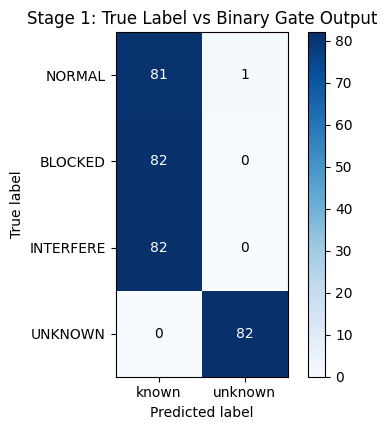

 accuracy  known_false_positive_rate  unknown_recall  fallback_threshold  total_prototypes  file_window_q  threshold_margin  ambiguity_ratio_threshold
 0.996951                   0.004065             1.0           11.863399                 6           0.94               1.5                       0.25

Per-class distance thresholds calibrated from per-file train+val scores:
 label class_name  threshold  base_file_score  train_files  val_files  calibration_files  num_prototypes cluster_sizes  silhouette_score  file_score_median  file_score_max                       calibration_mode  used_fallback
     0     NORMAL   5.153414         3.435610            5          2                  7               2     [106, 99]          0.470456           2.405873        3.435610 per-file train+val own-nearest windows          False
     1    BLOCKED  10.755088         7.170059            6          2                  8               2     [164, 82]          0.745528           2.676880        7.170059 

In [578]:
gatekeeper = fit_mahalanobis_gatekeeper(
    X_train_known,
    y_train_known_raw,
    X_val_known,
    y_val_known_raw,
    known_train_feature_groups,
    known_val_feature_groups,
)
gatekeeper_save_path = ANOMALY_GATE_ARTIFACT_PATH
save_mahalanobis_gatekeeper(
    gatekeeper_save_path,
    gatekeeper,
    mean=mean,
    std=std,
    window_len=target_len,
    preprocessor_name=selected_preprocessor_name,
    preprocessor_kwargs=selected_preprocessor_kwargs,
)
print(f"Saved anomaly detector artifact to {gatekeeper_save_path}")
stage1_test = predict_gatekeeper(gatekeeper, X_full_test)

y_stage1_true_binary = (y_full_test_raw == UNKNOWN_LABEL).astype(np.int64)
y_stage1_pred = stage1_test["is_unknown"]

stage1_cm = confusion_matrix(y_stage1_true_binary, y_stage1_pred, labels=[0, 1])
tn, fp, fn, tp = stage1_cm.ravel()
stage1_summary = pd.DataFrame([
    {
        "accuracy": accuracy_score(y_stage1_true_binary, y_stage1_pred),
        "known_false_positive_rate": fp / (fp + tn + 1e-12),
        "unknown_recall": tp / (tp + fn + 1e-12),
        "fallback_threshold": gatekeeper["fallback_threshold"],
        "total_prototypes": len(gatekeeper["prototype_table"]),
        "file_window_q": FILE_WINDOW_SCORE_Q,
        "threshold_margin": FILE_THRESHOLD_MARGIN,
        "ambiguity_ratio_threshold": gatekeeper["ambiguity_ratio_threshold"],
    }
])
threshold_table = pd.DataFrame([
    {
        "label": label,
        "class_name": LABEL_TO_NAME.get(label, str(label)),
        "threshold": details["threshold"],
        "base_file_score": details["base_file_score"],
        "train_files": details["num_train_files"],
        "val_files": details["num_val_files"],
        "calibration_files": details["num_calibration_files"],
        "num_prototypes": details["num_prototypes"],
        "cluster_sizes": details["cluster_sizes"],
        "silhouette_score": details["silhouette_score"],
        "file_score_median": details["file_score_median"],
        "file_score_max": details["file_score_max"],
        "calibration_mode": details["calibration_mode"],
        "used_fallback": details["used_fallback"],
    }
    for label, details in sorted(gatekeeper["threshold_details"].items())
])
stage1_true_label_order = known_labels + [UNKNOWN_LABEL]
stage1_true_vs_binary_cm = plot_true_label_binary_confusion(
    y_full_test_raw,
    y_stage1_pred,
    true_labels=stage1_true_label_order,
    true_display_labels=[LABEL_TO_NAME[label] for label in stage1_true_label_order],
    title="Stage 1: True Label vs Binary Gate Output",
    figsize=(5.6, 4.4),
)
stage1_true_vs_binary_df = pd.DataFrame(
    stage1_true_vs_binary_cm,
    index=[LABEL_TO_NAME[label] for label in stage1_true_label_order],
    columns=["known", "unknown"],
)
stage1_nearest_label_order = known_labels
stage1_true_vs_nearest_known_cm = np.zeros((len(stage1_true_label_order), len(stage1_nearest_label_order)), dtype=int)
for row, true_label in enumerate(stage1_true_label_order):
    mask = y_full_test_raw == true_label
    for col, pred_label in enumerate(stage1_nearest_label_order):
        stage1_true_vs_nearest_known_cm[row, col] = int(np.sum(mask & (stage1_test["nearest_label"] == pred_label)))
stage1_true_vs_nearest_known_df = pd.DataFrame(
    stage1_true_vs_nearest_known_cm,
    index=[LABEL_TO_NAME[label] for label in stage1_true_label_order],
    columns=[LABEL_TO_NAME[label] for label in stage1_nearest_label_order],
)
stage1_geometry_table = pd.DataFrame([
    {
        "true_label": LABEL_TO_NAME[label],
        "distance_median": float(np.median(stage1_test["distance"][y_full_test_raw == label])),
        "distance_max": float(np.max(stage1_test["distance"][y_full_test_raw == label])),
        "second_distance_median": float(np.median(stage1_test["second_distance"][y_full_test_raw == label])),
        "ratio_median": float(np.median(stage1_test["distance_ratio"][y_full_test_raw == label])),
        "ratio_max": float(np.max(stage1_test["distance_ratio"][y_full_test_raw == label])),
        "gap_median": float(np.median(stage1_test["distance_gap"][y_full_test_raw == label])),
    }
    for label in stage1_true_label_order
    if np.any(y_full_test_raw == label)
])
print(stage1_summary.to_string(index=False))
print()
print("Per-class distance thresholds calibrated from per-file train+val scores:")
print(threshold_table.to_string(index=False))
print()
print("Stage 1 confusion matrix with true labels on rows and binary gate output on columns:")
print(stage1_true_vs_binary_df.to_string())
print()
print("Nearest known label before thresholding:")
print(stage1_true_vs_nearest_known_df.to_string())
print()
print("Stage 1 distance and ambiguity stats by true label:")
print(stage1_geometry_table.to_string(index=False))
print()
print(classification_report(
    y_stage1_true_binary,
    y_stage1_pred,
    labels=[0, 1],
    target_names=["known", "unknown"],
    zero_division=0,
))


## Section 2: Fault classifier

Train the 1D CNN from `new2.ipynb` on the known labels only, then report the labelled confusion matrix on the known test split.
        

hybrid_timefreq epoch=01 train_loss=0.2635 val_loss=0.2382 val_acc=0.9951 lr=1.00e-03
hybrid_timefreq epoch=02 train_loss=0.1318 val_loss=0.1957 val_acc=1.0000 lr=1.00e-03
hybrid_timefreq epoch=03 train_loss=0.1214 val_loss=0.1879 val_acc=1.0000 lr=1.00e-03
hybrid_timefreq epoch=04 train_loss=0.1255 val_loss=0.1450 val_acc=1.0000 lr=1.00e-03
hybrid_timefreq epoch=05 train_loss=0.1270 val_loss=0.1539 val_acc=1.0000 lr=1.00e-03
hybrid_timefreq epoch=06 train_loss=0.1226 val_loss=0.1418 val_acc=1.0000 lr=1.00e-03
hybrid_timefreq epoch=07 train_loss=0.1204 val_loss=0.1419 val_acc=1.0000 lr=1.00e-03
hybrid_timefreq epoch=08 train_loss=0.1222 val_loss=0.1351 val_acc=1.0000 lr=1.00e-03
hybrid_timefreq epoch=09 train_loss=0.1331 val_loss=0.1740 val_acc=1.0000 lr=1.00e-03
hybrid_timefreq epoch=10 train_loss=0.1296 val_loss=0.1896 val_acc=1.0000 lr=1.00e-03
hybrid_timefreq epoch=11 train_loss=0.1249 val_loss=0.1301 val_acc=1.0000 lr=1.00e-03
hybrid_timefreq epoch=12 train_loss=0.1205 val_loss=0.

/tmp/ipykernel_5912/1866268872.py:233: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0317 19:48:49.021000 5912 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms


[torch.onnx] Obtain model graph for `HybridTimeFreq1DCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `HybridTimeFreq1DCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 13 of general pattern rewrite rules.
Saved ONNX classifier to /home/btanady/fourth_year/cpen491/experiment/weights/end_to_end_cnn1d_hybrid_calaug.onnx
Saved ONNX metadata to /home/btanady/fourth_year/cpen491/experiment/weights/end_to_end_cnn1d_hybrid_calaug.meta.json


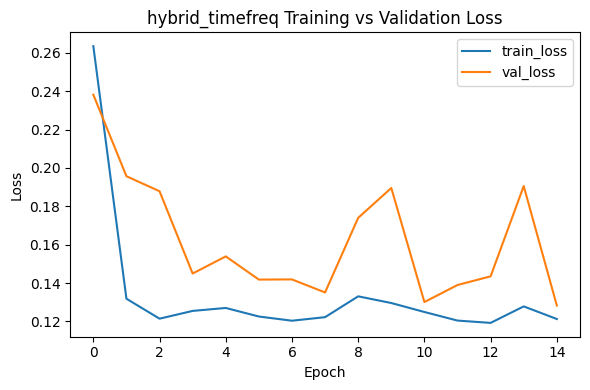

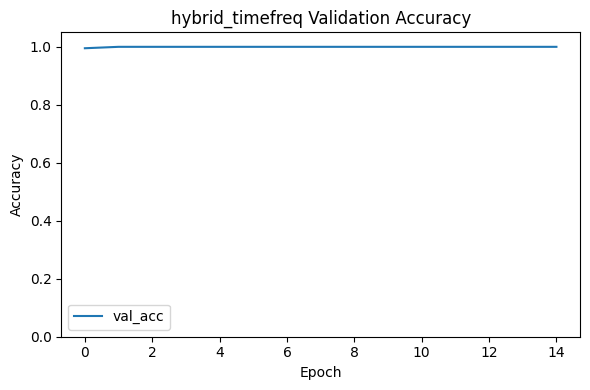

In [579]:
class ResBlock1D(nn.Module):
    def __init__(self, channels: int, kernel_size: int = 5, dilation: int = 1, dropout: float = 0.1):
        super().__init__()
        padding = dilation * (kernel_size // 2)
        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(channels),
        )
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.dropout(self.net(x)))


class Fan1DCNN(nn.Module):
    def __init__(self, n_classes: int, in_channels: int = 3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class HybridTimeFreq1DCNN(nn.Module):
    def __init__(self, n_classes: int, in_channels: int = 3, width: int = 48):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, width, kernel_size=9, padding=4),
            nn.BatchNorm1d(width),
            nn.GELU(),
        )
        self.time_branch = nn.Sequential(
            ResBlock1D(width, kernel_size=7, dilation=1, dropout=0.1),
            nn.MaxPool1d(2),
            ResBlock1D(width, kernel_size=5, dilation=2, dropout=0.1),
            nn.MaxPool1d(2),
            ResBlock1D(width, kernel_size=3, dilation=4, dropout=0.1),
            nn.AdaptiveAvgPool1d(1),
        )
        self.freq_branch = nn.Sequential(
            nn.Conv1d(in_channels, width, kernel_size=5, padding=2),
            nn.BatchNorm1d(width),
            nn.GELU(),
            ResBlock1D(width, kernel_size=5, dilation=1, dropout=0.1),
            nn.MaxPool1d(2),
            ResBlock1D(width, kernel_size=3, dilation=2, dropout=0.1),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(width * 2, 128),
            nn.GELU(),
            nn.Dropout(p=0.25),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        time_features = self.time_branch(self.stem(x))
        freq_input = torch.log1p(torch.abs(torch.fft.rfft(x, dim=2)))
        freq_features = self.freq_branch(freq_input)
        return self.classifier(torch.cat([time_features, freq_features], dim=1))


def build_classifier_model(n_classes: int) -> nn.Module:
    if CNN_ARCHITECTURE == "fan1d":
        return Fan1DCNN(n_classes=n_classes)
    if CNN_ARCHITECTURE == "hybrid_timefreq":
        return HybridTimeFreq1DCNN(n_classes=n_classes)
    raise ValueError(f"Unsupported CNN_ARCHITECTURE: {CNN_ARCHITECTURE}")


def make_loader(x_np, y_np, batch_size, shuffle):
    dataset = TensorDataset(torch.from_numpy(x_np).float(), torch.from_numpy(y_np).long())
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def reset_stage2_seeds(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def train_cnn_classifier(
    x_train,
    y_train,
    x_val,
    y_val,
    *,
    label_to_idx,
    idx_to_label,
    save_path,
):
    reset_stage2_seeds()

    train_loader = make_loader(x_train, y_train, CNN_BATCH_SIZE, shuffle=True)
    val_loader = make_loader(x_val, y_val, CNN_BATCH_SIZE, shuffle=False)

    model = build_classifier_model(n_classes=len(label_to_idx)).to(DEVICE)
    counts = np.bincount(y_train, minlength=len(label_to_idx)).astype(np.float32)
    class_weights = counts.sum() / np.maximum(counts * len(label_to_idx), 1.0)
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE),
        label_smoothing=CNN_LABEL_SMOOTHING,
    )
    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    @torch.no_grad()
    def evaluate(loader):
        model.eval()
        total_loss = 0.0
        all_true = []
        all_pred = []
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * yb.size(0)
            preds = torch.argmax(logits, dim=1)
            all_true.append(yb.cpu().numpy())
            all_pred.append(preds.cpu().numpy())

        y_true = np.concatenate(all_true)
        y_pred = np.concatenate(all_pred)
        avg_loss = total_loss / max(len(loader.dataset), 1)
        acc = accuracy_score(y_true, y_pred)
        return avg_loss, acc, y_true, y_pred

    def train_one_epoch(loader):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * yb.size(0)
        return total_loss / max(len(loader.dataset), 1)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_state = None
    best_metric = (-1.0, float("inf"))
    wait = 0

    for epoch in range(1, CNN_EPOCHS + 1):
        train_loss = train_one_epoch(train_loader)
        val_loss, val_acc, _, _ = evaluate(val_loader)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"{CNN_ARCHITECTURE} epoch={epoch:02d} train_loss={train_loss:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} lr={lr_now:.2e}"
        )

        metric = (val_acc, -val_loss)
        if metric > best_metric:
            best_metric = metric
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= CNN_EARLY_STOP_PATIENCE:
                print("Early stopping triggered.")
                break

    if best_state is None:
        raise RuntimeError("Training did not produce a valid CNN state.")

    model.load_state_dict(best_state)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "label_to_idx": label_to_idx,
            "idx_to_label": idx_to_label,
            "mean": classifier_mean.astype(np.float32),
            "std": classifier_std.astype(np.float32),
            "window_len": int(target_len),
            "architecture": CNN_ARCHITECTURE,
            "preprocessor_name": selected_preprocessor_name,
            "preprocessor_kwargs": selected_preprocessor_kwargs,
        },
        save_path,
    )
    print(f"Saved best {CNN_ARCHITECTURE} CNN to {save_path}")

    onnx_path = save_path.with_suffix(".onnx")
    meta_path = onnx_path.with_suffix(".meta.json")
    model.eval()
    dummy = torch.randn(1, 3, target_len, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        torch.onnx.export(
            model,
            dummy,
            onnx_path.as_posix(),
            export_params=True,
            do_constant_folding=True,
            input_names=["input"],
            output_names=["logits"],
            dynamic_axes={"input": {0: "batch_size"}, "logits": {0: "batch_size"}},
            opset_version=CNN_ONNX_OPSET,
        )

    meta = {
        "onnx_path": onnx_path.as_posix(),
        "input_shape": [1, 3, int(target_len)],
        "architecture": CNN_ARCHITECTURE,
        "embedder": {
            "name": "raw1dcnn",
            "kwargs": {
                "target_len": int(target_len),
                "mean": classifier_mean.reshape(-1).astype(float).tolist(),
                "std": classifier_std.reshape(-1).astype(float).tolist(),
            },
        },
        "preprocessor": {
            "name": selected_preprocessor_name,
            "kwargs": selected_preprocessor_kwargs,
        },
        "labels": {int(k): int(v) for k, v in idx_to_label.items()},
    }
    meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    print(f"Saved ONNX classifier to {onnx_path}")
    print(f"Saved ONNX metadata to {meta_path}")

    return {
        "model": model,
        "history": history,
        "label_to_idx": label_to_idx,
        "idx_to_label": idx_to_label,
        "save_path": save_path,
        "onnx_path": onnx_path,
        "meta_path": meta_path,
    }


@torch.no_grad()
def predict_cnn(bundle, x_np, batch_size=256):
    model = bundle["model"]
    model.eval()
    preds = []
    for start in range(0, len(x_np), batch_size):
        xb = torch.from_numpy(x_np[start:start + batch_size]).float().to(DEVICE)
        logits = model(xb)
        pred_idx = torch.argmax(logits, dim=1).cpu().numpy()
        preds.append(pred_idx)
    pred_idx = np.concatenate(preds)
    return np.array([bundle["idx_to_label"][int(idx)] for idx in pred_idx], dtype=np.int64)



if True:
    classifier_bundle = train_cnn_classifier(
        X_train_classifier,
        y_train_classifier,
        X_val_classifier_input,
        y_val_classifier,
        label_to_idx=classifier_label_to_idx,
        idx_to_label=classifier_idx_to_label,
        save_path=CLASSIFIER_ARTIFACT_PATH,
    )
    classifier_bundle["backend"] = "cnn1d"

    plt.figure(figsize=(6, 4))
    plt.plot(classifier_bundle["history"]["train_loss"], label="train_loss")
    plt.plot(classifier_bundle["history"]["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{CNN_ARCHITECTURE} Training vs Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(classifier_bundle["history"]["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.title(f"{CNN_ARCHITECTURE} Validation Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()


Known-class test accuracy: 1.000

              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00        82
     BLOCKED       1.00      1.00      1.00        82
   INTERFERE       1.00      1.00      1.00        82

    accuracy                           1.00       246
   macro avg       1.00      1.00      1.00       246
weighted avg       1.00      1.00      1.00       246



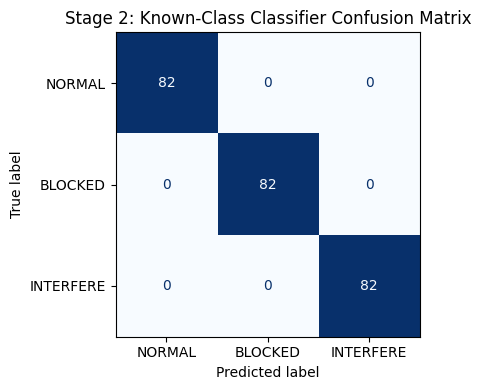

array([[82,  0,  0],
       [ 0, 82,  0],
       [ 0,  0, 82]])

In [580]:
y_known_test_pred = predict_cnn(classifier_bundle, X_known_test_classifier_input)

print(f"Known-class test accuracy: {accuracy_score(y_known_test_raw, y_known_test_pred):.3f}")
print()
print(classification_report(
    y_known_test_raw,
    y_known_test_pred,
    labels=known_labels,
    target_names=[LABEL_TO_NAME[label] for label in known_labels],
    zero_division=0,
))
plot_confusion(
    y_known_test_raw,
    y_known_test_pred,
    labels=known_labels,
    display_labels=[LABEL_TO_NAME[label] for label in known_labels],
    title="Stage 2: Known-Class Classifier Confusion Matrix",
    figsize=(4.8, 4.0),
)


## Evaluation

Run the full cascade on the held-out test split. Stage 1 decides whether a sample is unknown. Only samples kept as known are allowed through to the CNN classifier.
        

 combined_accuracy  num_known_test_windows  num_unknown_test_windows  predicted_unknown_windows
          0.996951                     246                        82                         83

              precision    recall  f1-score   support

      NORMAL       1.00      0.99      0.99        82
     BLOCKED       1.00      1.00      1.00        82
   INTERFERE       1.00      1.00      1.00        82
     UNKNOWN       0.99      1.00      0.99        82

    accuracy                           1.00       328
   macro avg       1.00      1.00      1.00       328
weighted avg       1.00      1.00      1.00       328



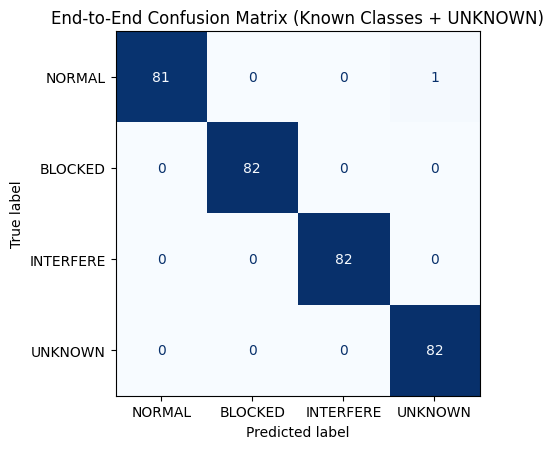

array([[81,  0,  0,  1],
       [ 0, 82,  0,  0],
       [ 0,  0, 82,  0],
       [ 0,  0,  0, 82]])

In [581]:
y_full_classifier_pred = predict_cnn(classifier_bundle, X_full_test_classifier_input)
y_combined_pred = np.where(y_stage1_pred == 1, UNKNOWN_LABEL, y_full_classifier_pred)

combined_labels = known_labels + [UNKNOWN_LABEL]
combined_summary = pd.DataFrame([
    {
        "combined_accuracy": accuracy_score(y_full_test_raw, y_combined_pred),
        "num_known_test_windows": int(np.sum(y_full_test_raw != UNKNOWN_LABEL)),
        "num_unknown_test_windows": int(np.sum(y_full_test_raw == UNKNOWN_LABEL)),
        "predicted_unknown_windows": int(np.sum(y_combined_pred == UNKNOWN_LABEL)),
    }
])
print(combined_summary.to_string(index=False))
print()
print(classification_report(
    y_full_test_raw,
    y_combined_pred,
    labels=combined_labels,
    target_names=[LABEL_TO_NAME[label] for label in combined_labels],
    zero_division=0,
))
plot_confusion(
    y_full_test_raw,
    y_combined_pred,
    labels=combined_labels,
    display_labels=[LABEL_TO_NAME[label] for label in combined_labels],
    title="End-to-End Confusion Matrix (Known Classes + UNKNOWN)",
    figsize=(5.6, 4.6),
)


In [582]:
import shlex


def _display_path(path_like) -> str:
    path = Path(path_like)
    try:
        return path.relative_to(ROOT).as_posix()
    except ValueError:
        return path.as_posix()


broker_model_path = _display_path(classifier_bundle["onnx_path"])
broker_gate_path = _display_path(gatekeeper_save_path)

broker_cmd = "\n".join([
    "python -m fdd_system.broker.main \\",
    "  --port /dev/ttyACM0 \\",
    "  --baudrate 115200 \\",
    "  --input-format bin \\",
    "  --fs-hz 800 \\",
    f"  --model-path {shlex.quote(broker_model_path)} \\",
    "  --model-format onnx \\",
    "  --embedder auto \\",
    "  --preprocessor auto \\",
    f"  --anomaly-detector-path {shlex.quote(broker_gate_path)} \\",
    "  --calibration-seconds 20 \\",
    "  --calibration-discard-seconds 2 \\",
    "  --gate-runtime-calibration",
])

print("Broker launch command:")
print(broker_cmd)


Broker launch command:
python -m fdd_system.broker.main \
  --port /dev/ttyACM0 \
  --baudrate 115200 \
  --input-format bin \
  --fs-hz 800 \
  --model-path experiment/weights/end_to_end_cnn1d_hybrid_calaug.onnx \
  --model-format onnx \
  --embedder auto \
  --preprocessor auto \
  --anomaly-detector-path experiment/weights/end_to_end_anomaly_gate.pt \
  --calibration-seconds 20 \
  --calibration-discard-seconds 2 \
  --gate-runtime-calibration
